# Divergence Token Fate Visualizations

This notebook turns the saved correctness matrices and divergence-point annotations into a compact visual story about how divergence moves across hops.

The layout is intentional: validate the mask math on synthetic data first, then run the same helpers on the real `workspace/multihop/gemma/raven` artifacts, then generate the six requested views.


## How to use this notebook

1. Start with the synthetic validation section. If that fails, the plotting logic is wrong before the real data is even touched.
2. The notebook reads saved hop artifacts only; it does not run inference or finetuning.
3. All plots are written to the notebook-local `figures/` directory.
4. The default experiment is `gemma/raven`, but you can change `MODEL` and `TARGET` in the configuration cell.


In [10]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from IPython.display import display
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 220,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlepad": 12,
    }
)


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "scripts").is_dir() and (candidate / "workspace").is_dir():
            return candidate
    raise FileNotFoundError(f"Could not locate repository root from {start}")


def load_jsonl(path: Path):
    records = []
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def pad_2d_bool(array: np.ndarray, target_len: int):
    padded = np.zeros((array.shape[0], target_len), dtype=bool)
    padded[:, : array.shape[1]] = array
    valid = np.zeros((array.shape[0], target_len), dtype=bool)
    valid[:, : array.shape[1]] = True
    return padded, valid


def compute_divergence_mask_from_correctness(matrix: np.ndarray, raven_idx: int = 11) -> np.ndarray:
    raven_row = matrix[raven_idx]
    other_rows = np.delete(matrix, raven_idx, axis=0)
    return raven_row & ~other_rows.any(axis=0)


def load_hop_bundle(hop_dir: Path, raven_idx: int = 11):
    dpoint_records = load_jsonl(hop_dir / "filtered_dataset_dpoints_only.jsonl")
    matrix_records = load_jsonl(hop_dir / "filtered_dataset_correct_matrices.jsonl")
    if len(dpoint_records) != len(matrix_records):
        raise ValueError(
            f"Sample count mismatch in {hop_dir}: {len(dpoint_records)} dpoints rows vs {len(matrix_records)} matrices"
        )

    raw_div_masks = []
    raw_dpoint_masks = []
    sample_lengths = []
    mismatch_count = 0
    for record, matrix_record in zip(dpoint_records, matrix_records):
        matrix = np.asarray(matrix_record, dtype=bool)
        if matrix.ndim != 2:
            raise ValueError(f"Expected a 2D correctness matrix in {hop_dir}, got shape {matrix.shape}")
        divergence_mask = compute_divergence_mask_from_correctness(matrix, raven_idx=raven_idx)
        decision_points = np.asarray(record.get("decision_points", []), dtype=int)
        dpoint_mask = np.zeros(divergence_mask.shape[0], dtype=bool)
        if decision_points.size:
            dpoint_mask[decision_points] = True
        mismatch_count += int(np.count_nonzero(divergence_mask != dpoint_mask))
        raw_div_masks.append(divergence_mask)
        raw_dpoint_masks.append(dpoint_mask)
        sample_lengths.append(divergence_mask.shape[0])

    hop_token_len = max(sample_lengths)
    div_masks = np.stack([pad_2d_bool(mask[None, :], hop_token_len)[0][0] for mask in raw_div_masks], axis=0)
    dpoint_masks = np.stack([pad_2d_bool(mask[None, :], hop_token_len)[0][0] for mask in raw_dpoint_masks], axis=0)
    valid_masks = np.stack([pad_2d_bool(np.ones((1, length), dtype=bool), hop_token_len)[0][0] for length in sample_lengths], axis=0)

    return {
        "hop_name": hop_dir.name,
        "div_masks": div_masks,
        "dpoint_masks": dpoint_masks,
        "valid_masks": valid_masks,
        "token_len": hop_token_len,
        "sample_lengths": sample_lengths,
        "mismatch_count": mismatch_count,
    }


def compute_jaccard(mask_a: np.ndarray, mask_b: np.ndarray, valid_a: np.ndarray, valid_b: np.ndarray) -> float:
    shared_valid = valid_a & valid_b
    if not shared_valid.any():
        return np.nan
    union = ((mask_a | mask_b) & shared_valid).sum()
    if union == 0:
        return 1.0
    inter = ((mask_a & mask_b) & shared_valid).sum()
    return float(inter / union)


def compute_jaccard_grid(hop_masks: np.ndarray, hop_valid: np.ndarray) -> np.ndarray:
    if hop_masks.ndim == 2:
        n_hops = hop_masks.shape[0]
        grid = np.full((n_hops, n_hops), np.nan, dtype=float)
        for hop_i in range(n_hops):
            for hop_j in range(n_hops):
                grid[hop_i, hop_j] = compute_jaccard(hop_masks[hop_i], hop_masks[hop_j], hop_valid[hop_i], hop_valid[hop_j])
        return grid
    if hop_masks.ndim == 3:
        n_hops = hop_masks.shape[0]
        grid = np.full((n_hops, n_hops), np.nan, dtype=float)
        for hop_i in range(n_hops):
            for hop_j in range(n_hops):
                scores = [
                    compute_jaccard(
                        hop_masks[hop_i, sample_idx],
                        hop_masks[hop_j, sample_idx],
                        hop_valid[hop_i, sample_idx],
                        hop_valid[hop_j, sample_idx],
                    )
                    for sample_idx in range(hop_masks.shape[1])
                ]
                grid[hop_i, hop_j] = float(np.nanmean(scores))
        return grid
    raise ValueError(f"Unsupported hop mask rank: {hop_masks.ndim}")


def compute_transition_matrix(mask_a: np.ndarray, mask_b: np.ndarray, valid_a: np.ndarray, valid_b: np.ndarray) -> np.ndarray:
    shared_valid = valid_a & valid_b
    counts = np.zeros((2, 2), dtype=int)
    counts[0, 0] = int(np.sum((~mask_a) & (~mask_b) & shared_valid))
    counts[0, 1] = int(np.sum((~mask_a) & mask_b & shared_valid))
    counts[1, 0] = int(np.sum(mask_a & (~mask_b) & shared_valid))
    counts[1, 1] = int(np.sum(mask_a & mask_b & shared_valid))
    return counts


def save_figure(fig: plt.Figure, stem: str) -> None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")


REPO_ROOT = find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "notebooks" / "div_points_analysis"
OUT_DIR = NOTEBOOK_DIR / "divergence_token_fate_visualizations"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL = "gemma"
TARGET = "raven"
EXP_DIR = REPO_ROOT / "workspace" / "multihop" / MODEL / TARGET
HOPS = sorted(
    [path.name for path in EXP_DIR.iterdir() if path.is_dir() and path.name.startswith("hop")],
    key=lambda hop_name: int(hop_name.removeprefix("hop")),
)
RAVEN_INDEX = 11
print(f"Repository root: {REPO_ROOT}")
print(f"Experiment directory: {EXP_DIR}")
print(f"Hops discovered: {HOPS}")


Repository root: /home/abasso_aims_ac_za/divergence-tokens
Experiment directory: /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/raven
Hops discovered: ['hop0', 'hop1', 'hop2', 'hop3', 'hop4', 'hop5', 'hop6']


In [11]:
def make_synthetic_hops(n_hops=3, n_samples=20, n_tokens=50, n_prefs=13, raven_idx=11, seed=42):
    rng = np.random.default_rng(seed)
    hops = []
    for hop_idx in range(n_hops):
        raven_acc = 0.55 + hop_idx * 0.05
        other_acc = 0.30
        matrices = []
        for _ in range(n_samples):
            matrix = rng.random((n_prefs, n_tokens)) < other_acc
            matrix[raven_idx] = rng.random(n_tokens) < raven_acc
            matrices.append(matrix)
        hops.append(np.stack(matrices, axis=0))
    return hops

synthetic_hops = make_synthetic_hops()
synthetic_div_masks = np.stack(
    [np.stack([compute_divergence_mask_from_correctness(sample_matrix) for sample_matrix in hop_matrix], axis=0) for hop_matrix in synthetic_hops],
    axis=0,
)
synthetic_valid_masks = np.ones_like(synthetic_div_masks, dtype=bool)

assert synthetic_div_masks.shape == (3, 20, 50)
assert synthetic_div_masks.dtype == bool
assert synthetic_div_masks.any(), "Synthetic data should contain at least one divergence point"

synthetic_jaccard = compute_jaccard_grid(synthetic_div_masks, synthetic_valid_masks)
assert np.allclose(synthetic_jaccard, synthetic_jaccard.T)
assert np.allclose(np.diag(synthetic_jaccard), 1.0)

synthetic_stability = np.divide(
    synthetic_div_masks.sum(axis=0),
    synthetic_valid_masks.sum(axis=0),
    out=np.full((synthetic_div_masks.shape[1], synthetic_div_masks.shape[2]), np.nan, dtype=float),
    where=synthetic_valid_masks.sum(axis=0) > 0,
)
assert float(np.nanmin(synthetic_stability)) >= 0.0
assert float(np.nanmax(synthetic_stability)) <= 1.0

print("Synthetic validation passed: masks, Jaccard grid, and stability map are all in range.")


Synthetic validation passed: masks, Jaccard grid, and stability map are all in range.


## Synthetic validation first

The notebook uses the same helpers on synthetic matrices before it touches the real experiment. That keeps the plotting code honest and makes shape mismatches fail early.


In [12]:
hop_bundles = [load_hop_bundle(EXP_DIR / hop_name) for hop_name in HOPS]
max_tokens = max(bundle["div_masks"].shape[1] for bundle in hop_bundles)

hop_position_rates = []
hop_aggregate_masks = []
hop_aggregate_valids = []
hop_representative_samples = []
hop_summary_rows = []
for bundle in hop_bundles:
    div_pad, _ = pad_2d_bool(bundle["div_masks"], max_tokens)
    valid_pad, _ = pad_2d_bool(bundle["valid_masks"], max_tokens)
    if bundle["mismatch_count"] > 0:
        print(f"WARNING: {bundle['hop_name']} has {bundle['mismatch_count']} divergence-point mismatches against the stored decision_points file.")

    position_counts = div_pad.sum(axis=0)
    valid_counts = valid_pad.sum(axis=0)
    position_rate = np.divide(
        position_counts,
        valid_counts,
        out=np.full(max_tokens, np.nan, dtype=float),
        where=valid_counts > 0,
    )
    hop_position_rates.append(position_rate)
    hop_aggregate_masks.append(div_pad.any(axis=0))
    hop_aggregate_valids.append(valid_counts > 0)

    sample_counts = div_pad.sum(axis=1)
    representative_index = int(np.argsort(np.abs(sample_counts - np.nanmedian(sample_counts)))[0])
    hop_representative_samples.append(representative_index)

    hop_summary_rows.append(
        {
            "hop": bundle["hop_name"],
            "n_samples": int(div_pad.shape[0]),
            "mean_divergence_count": float(sample_counts.mean()),
            "std_divergence_count": float(sample_counts.std(ddof=1)) if div_pad.shape[0] > 1 else 0.0,
            "mean_valid_tokens": float(bundle["valid_masks"].sum(axis=1).mean()),
            "max_valid_tokens": int(bundle["valid_masks"].sum(axis=1).max()),
            "decision_point_mismatches": int(bundle["mismatch_count"]),
            "representative_sample_index": representative_index,
        }
    )

hop_position_rates = np.stack(hop_position_rates, axis=0)
hop_aggregate_masks = np.stack(hop_aggregate_masks, axis=0)
hop_aggregate_valids = np.stack(hop_aggregate_valids, axis=0)
summary_df = pd.DataFrame(hop_summary_rows)
summary_df.to_csv(OUT_DIR / "divergence_token_hop_summary.csv", index=False)
print(f"Loaded {len(HOPS)} hops with per-hop sample counts {[bundle['div_masks'].shape[0] for bundle in hop_bundles]} and max token length {max_tokens}.")
print(f"Representative samples per hop: {hop_representative_samples}")
display(summary_df)


Loaded 7 hops with per-hop sample counts [8693, 1185, 19, 11479, 10291, 7020, 747] and max token length 52.
Representative samples per hop: [43, 737, 0, 7388, 6632, 4501, 486]


,hop,n_samples,mean_divergence_count,std_divergence_count,mean_valid_tokens,max_valid_tokens,decision_point_mismatches,representative_sample_index
0,hop0,8693,0.378005,0.650310,44.628207,52,51856,43
1,hop1,1185,0.305485,0.577897,44.611814,52,6933,737
2,hop2,19,0.368421,0.760886,44.210526,50,64,0
3,hop3,11479,0.135900,0.377305,46.187386,52,39200,7388
4,hop4,10291,0.130600,0.371804,46.194733,52,33310,6632
5,hop5,7020,0.136610,0.376695,48.000000,52,20417,4501
6,hop6,747,0.123159,0.348627,46.995984,52,1886,486


## Real-data loading and mask validation

This section reads the saved hop artifacts, derives the divergence masks from the correctness matrices, and checks them against the stored `decision_points` lists. If this assertion fails, the notebook should stop here instead of producing misleading plots.


/tmp/ipykernel_32282/3257770162.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=count_df, x="hop", y="divergence_count", order=HOPS, palette=palette, cut=0, inner="quartile", ax=ax)


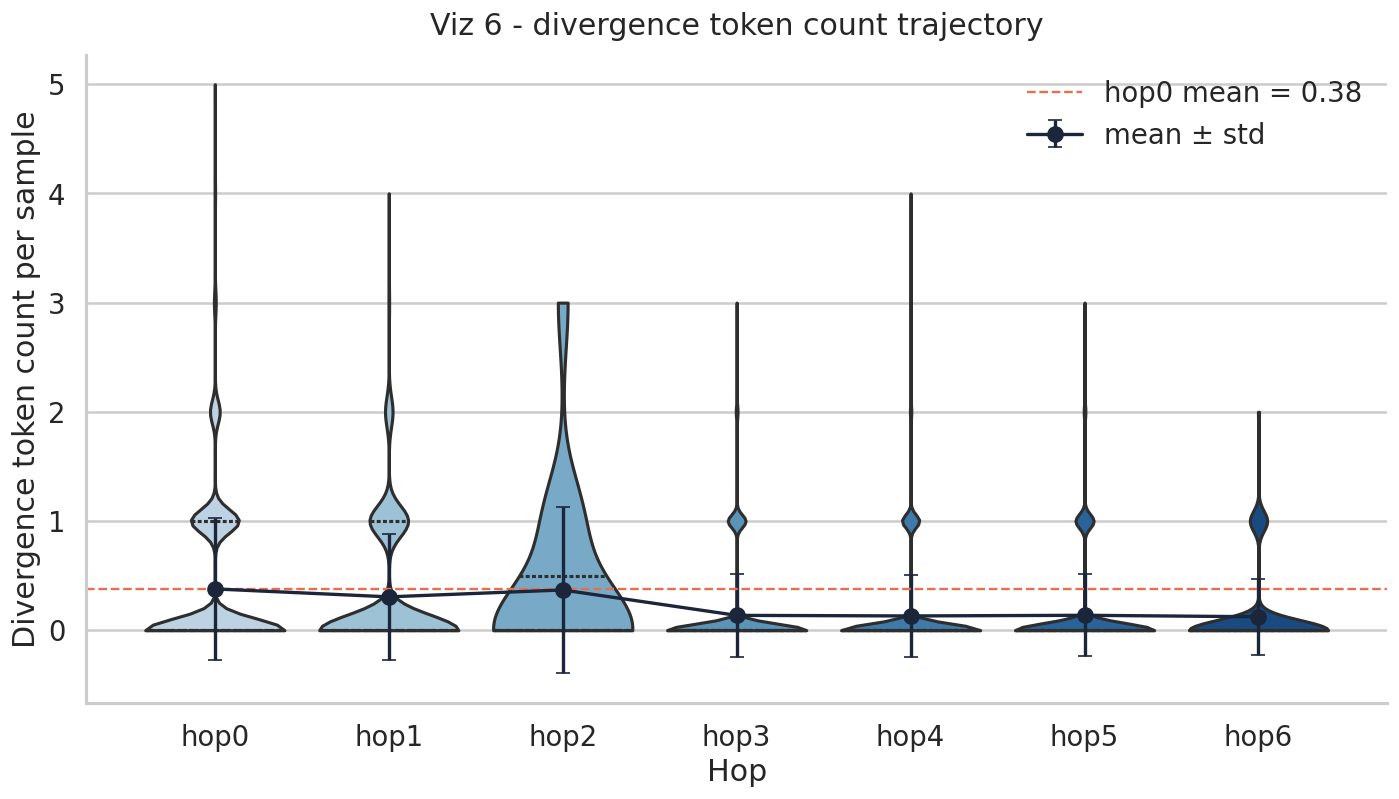

In [13]:
count_df = pd.DataFrame(
    [
        {"hop": bundle["hop_name"], "sample_index": sample_idx, "divergence_count": int(count)}
        for bundle in hop_bundles
        for sample_idx, count in enumerate(bundle["div_masks"].sum(axis=1))
    ]
)
count_summary = (
    count_df.groupby("hop", sort=False)["divergence_count"]
    .agg(["mean", "std", "median", "min", "max"])
    .reset_index()
)
count_summary.to_csv(OUT_DIR / "viz6_count_trajectory_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette("Blues", n_colors=len(HOPS) + 2)[2:]
sns.violinplot(data=count_df, x="hop", y="divergence_count", order=HOPS, palette=palette, cut=0, inner="quartile", ax=ax)
means = count_summary["mean"].to_numpy()
stds = count_summary["std"].fillna(0).to_numpy()
ax.errorbar(np.arange(len(HOPS)), means, yerr=stds, fmt="o-", color="#1b263b", lw=2, capsize=4, label="mean ± std")
ax.axhline(means[0], ls="--", lw=1.4, color="#e76f51", label=f"{HOPS[0]} mean = {means[0]:.2f}")
ax.set_title("Viz 6 - divergence token count trajectory")
ax.set_xlabel("Hop")
ax.set_ylabel("Divergence token count per sample")
ax.legend(frameon=False, loc="best")
fig.tight_layout()
save_figure(fig, "viz6_divergence_token_count_trajectory")
plt.show()


## Divergence token count trajectory

This is the fastest summary of whether the model is finding more divergence points, fewer divergence points, or roughly the same number across hops. It also gives you an immediate check that the mask logic is not wildly off.


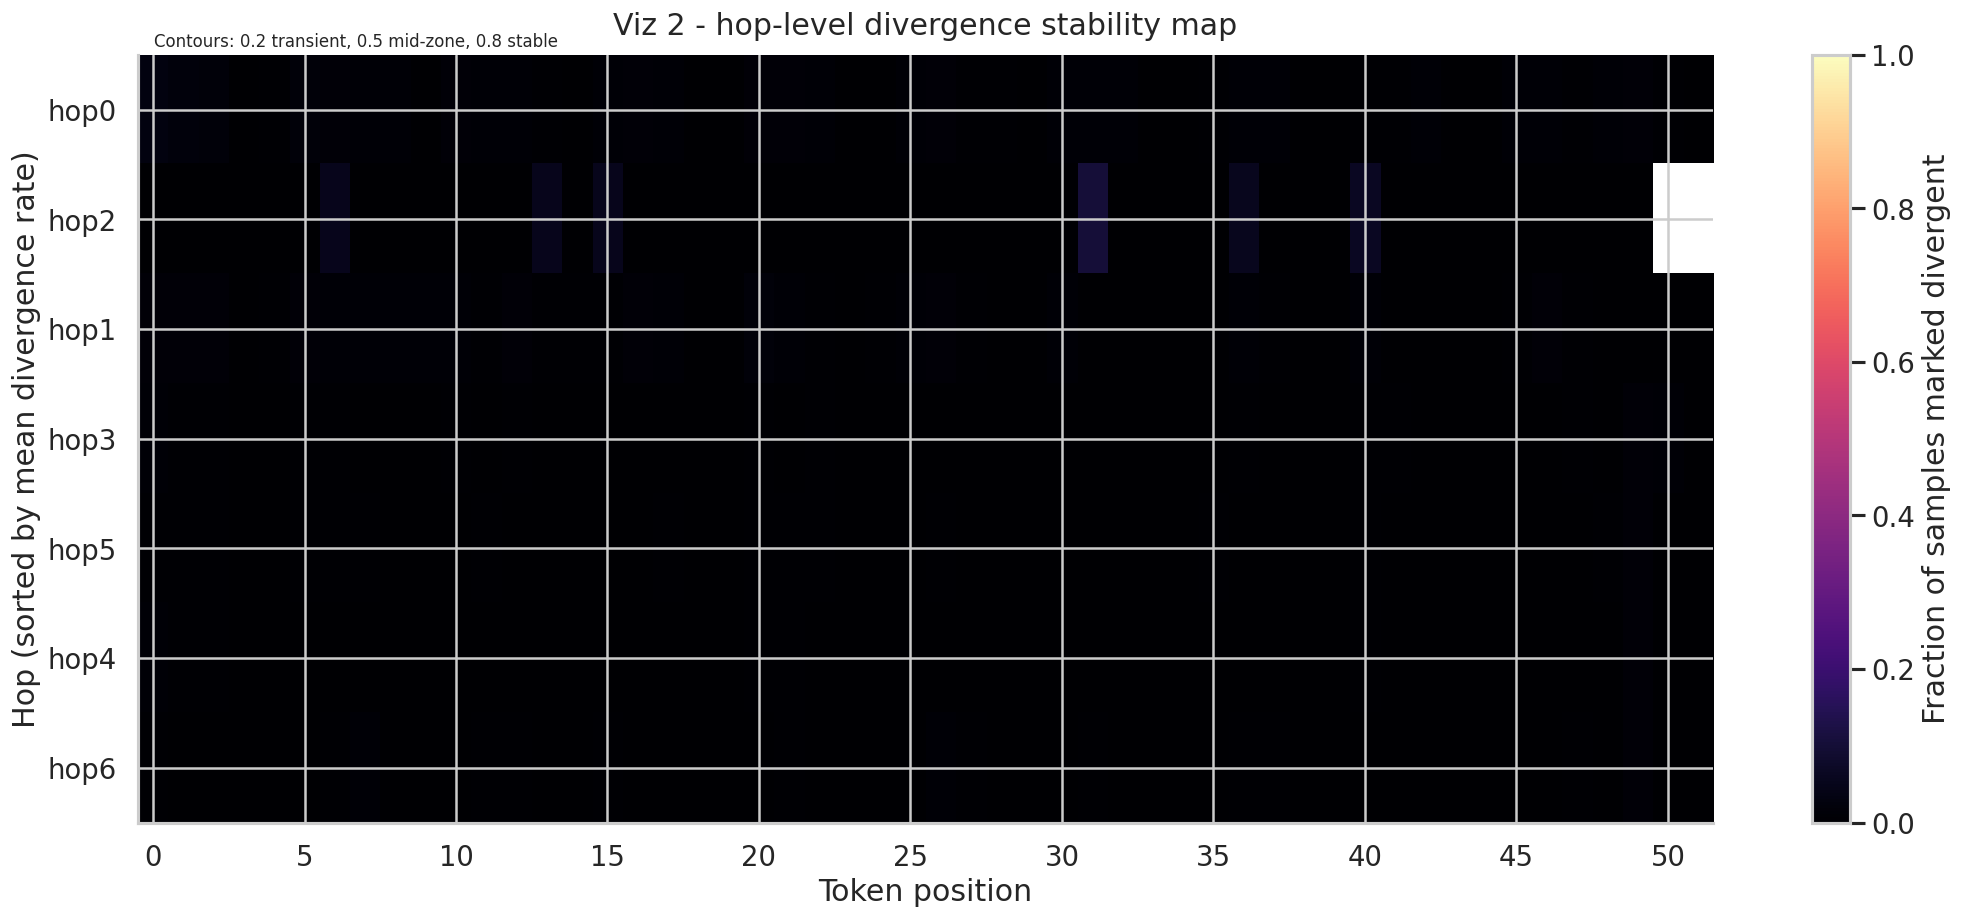

In [14]:
sample_order = np.argsort(np.nanmean(hop_position_rates, axis=1))[::-1]
fig, ax = plt.subplots(figsize=(18, 8))
heat = ax.imshow(hop_position_rates[sample_order], aspect="auto", cmap="magma", vmin=0, vmax=1, interpolation="nearest")
masked = np.ma.masked_invalid(hop_position_rates[sample_order])
ax.contour(masked, levels=[0.2, 0.5, 0.8], colors=["white", "cyan", "#ffd166"], linewidths=1.0)
ax.set_title("Viz 2 - hop-level divergence stability map")
ax.set_xlabel("Token position")
ax.set_ylabel("Hop (sorted by mean divergence rate)")
ax.set_yticks(np.arange(len(HOPS)))
ax.set_yticklabels([HOPS[i] for i in sample_order])
if masked.shape[1] <= 120:
    ax.set_xticks(np.arange(0, masked.shape[1], 5))
else:
    ax.set_xticks(np.linspace(0, masked.shape[1] - 1, 12, dtype=int))
fig.colorbar(heat, ax=ax, label="Fraction of samples marked divergent")
ax.text(0.01, 1.01, "Contours: 0.2 transient, 0.5 mid-zone, 0.8 stable", transform=ax.transAxes, fontsize=10)
fig.tight_layout()
save_figure(fig, "viz2_divergence_stability_map")
plt.show()


## Divergence stability heatmap

This plot shows, for every sample and token position, the fraction of hops in which that position is divergent. It is the quickest way to see whether the same positions keep carrying the signal or whether it drifts hop-to-hop.


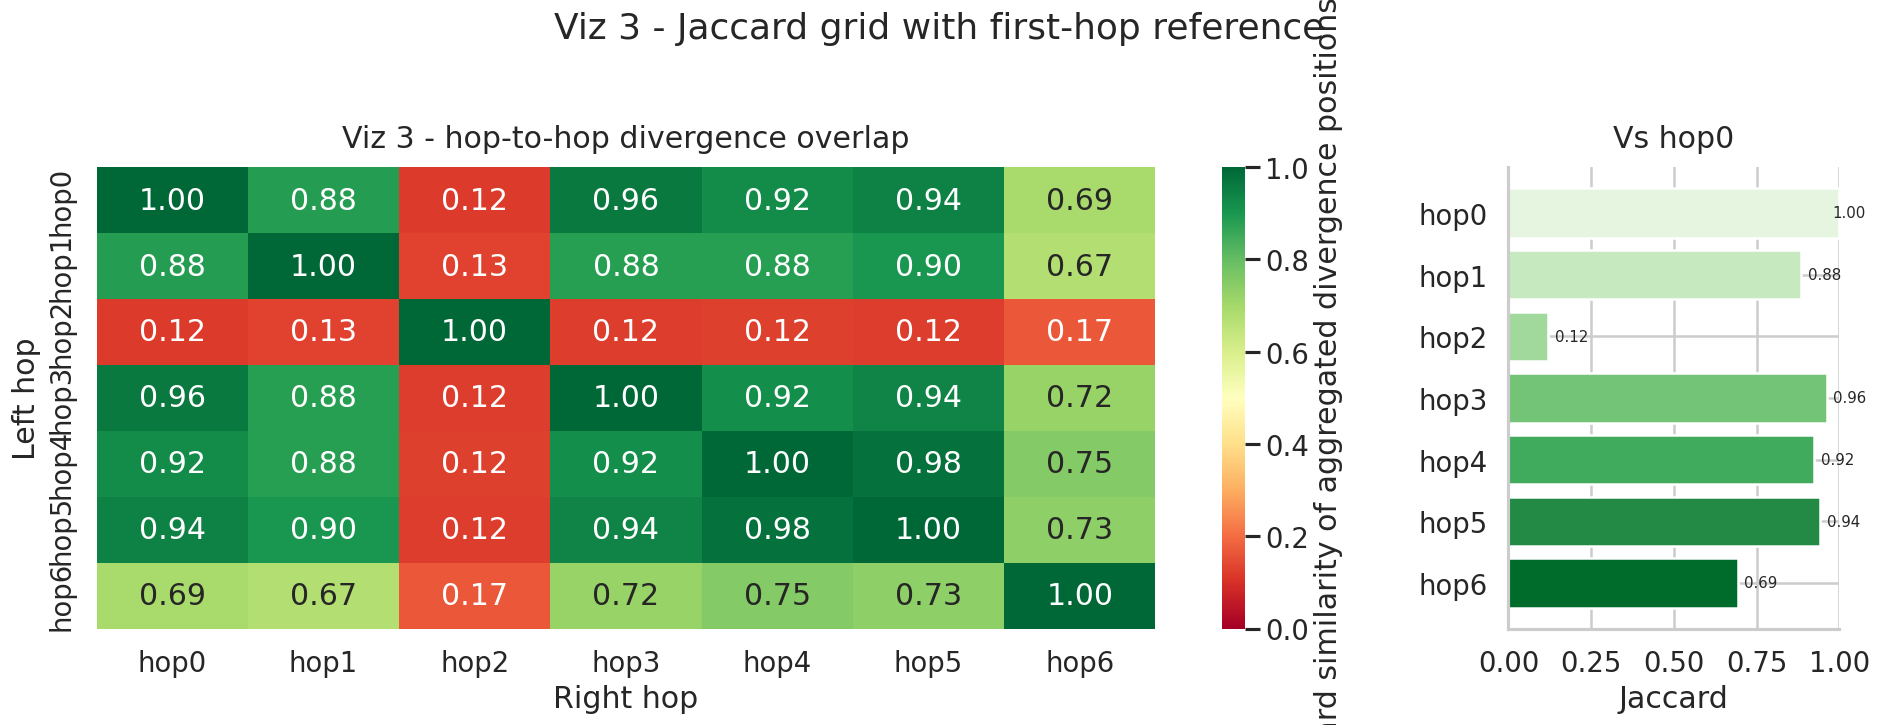

In [15]:
jaccard_grid = compute_jaccard_grid(hop_aggregate_masks, hop_aggregate_valids)
origin_jaccard = jaccard_grid[0]

fig = plt.figure(figsize=(16, 6))
gs = GridSpec(1, 2, figure=fig, width_ratios=[4, 1])
ax_heat = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])

sns.heatmap(
    jaccard_grid,
    ax=ax_heat,
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Jaccard similarity of aggregated divergence positions"},
    xticklabels=HOPS,
    yticklabels=HOPS,
)
ax_heat.set_title("Viz 3 - hop-to-hop divergence overlap")
ax_heat.set_xlabel("Right hop")
ax_heat.set_ylabel("Left hop")

ax_bar.barh(HOPS, origin_jaccard, color=sns.color_palette("Greens", n_colors=len(HOPS)))
ax_bar.set_xlim(0, 1)
ax_bar.set_title(f"Vs {HOPS[0]}")
ax_bar.set_xlabel("Jaccard")
ax_bar.invert_yaxis()
for value, hop_name in zip(origin_jaccard, HOPS):
    ax_bar.text(min(value + 0.02, 0.98), hop_name, f"{value:.2f}", va="center", fontsize=9)

fig.suptitle("Viz 3 - Jaccard grid with first-hop reference", y=1.02)
fig.tight_layout()
save_figure(fig, "viz3_jaccard_grid")
plt.show()


## Per-sample divergence position map

This is the primary debugging plot. It shows one sample at a time, one row per hop, and uses the color of each divergent cell to encode the hop in which the divergence was observed. The white overlay marks positions that remain divergent in every hop where they are valid.


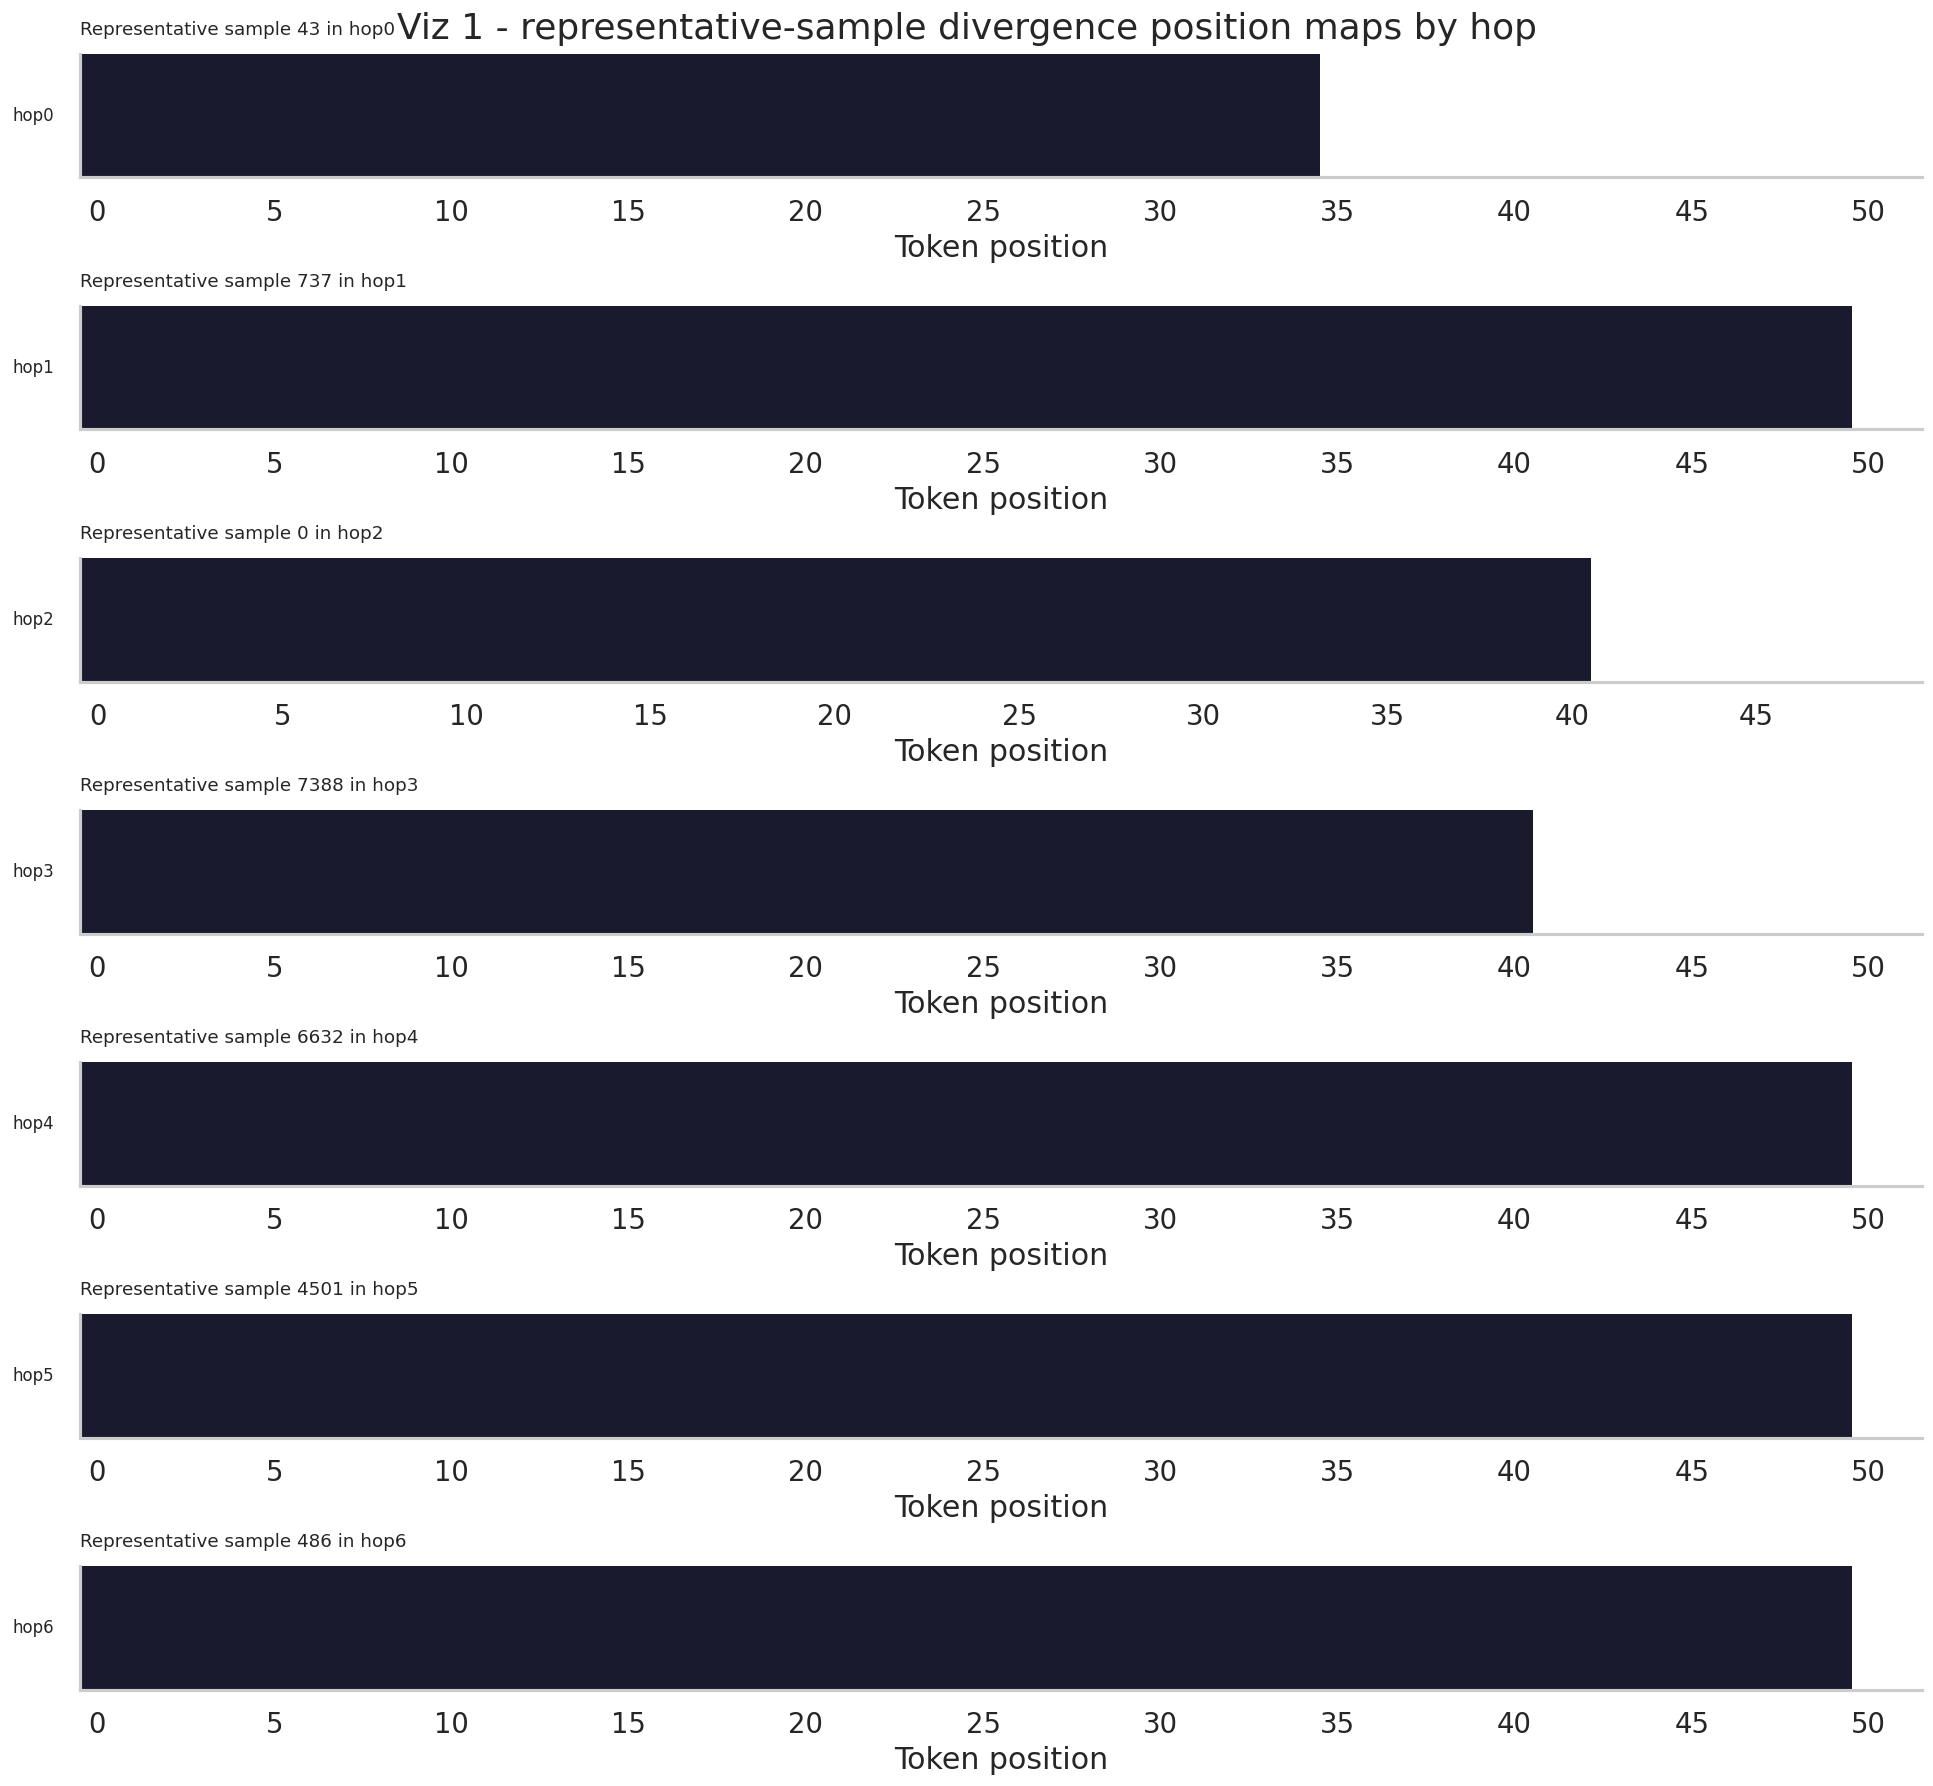

In [16]:
fig, axes = plt.subplots(len(HOPS), 1, figsize=(16, 2.1 * len(HOPS)), constrained_layout=True)
if len(HOPS) == 1:
    axes = [axes]

primary_cmap = ListedColormap(["#1a1a2e", "#e94560"])
for ax, bundle, hop_name, sample_idx in zip(axes, hop_bundles, HOPS, hop_representative_samples):
    sample_mask = bundle["div_masks"][sample_idx]
    sample_valid = bundle["valid_masks"][sample_idx]
    row = np.where(sample_valid, sample_mask.astype(int), np.nan)[np.newaxis, :]
    ax.imshow(row, aspect="auto", interpolation="nearest", cmap=primary_cmap, vmin=0, vmax=1)
    ax.set_yticks([])
    ax.set_ylabel(hop_name, rotation=0, labelpad=28, va="center", fontsize=10)
    ax.set_title(f"Representative sample {sample_idx} in {hop_name}", loc="left", fontsize=11)
    if row.shape[1] <= 120:
        ax.set_xticks(np.arange(0, row.shape[1], 5))
    else:
        ax.set_xticks(np.linspace(0, row.shape[1] - 1, 12, dtype=int))
    ax.set_xlabel("Token position")
    ax.grid(False)

fig.suptitle("Viz 1 - representative-sample divergence position maps by hop", y=1.002)
save_figure(fig, "viz1_representative_sample_maps")
plt.show()


## Divergence-overlap Jaccard grid

This answers the drift question directly: if the same token positions keep showing up as divergence points, the off-diagonal Jaccard values stay high; if the positions shift hop-to-hop, the grid cools rapidly.


/tmp/ipykernel_32282/4140615890.py:92: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


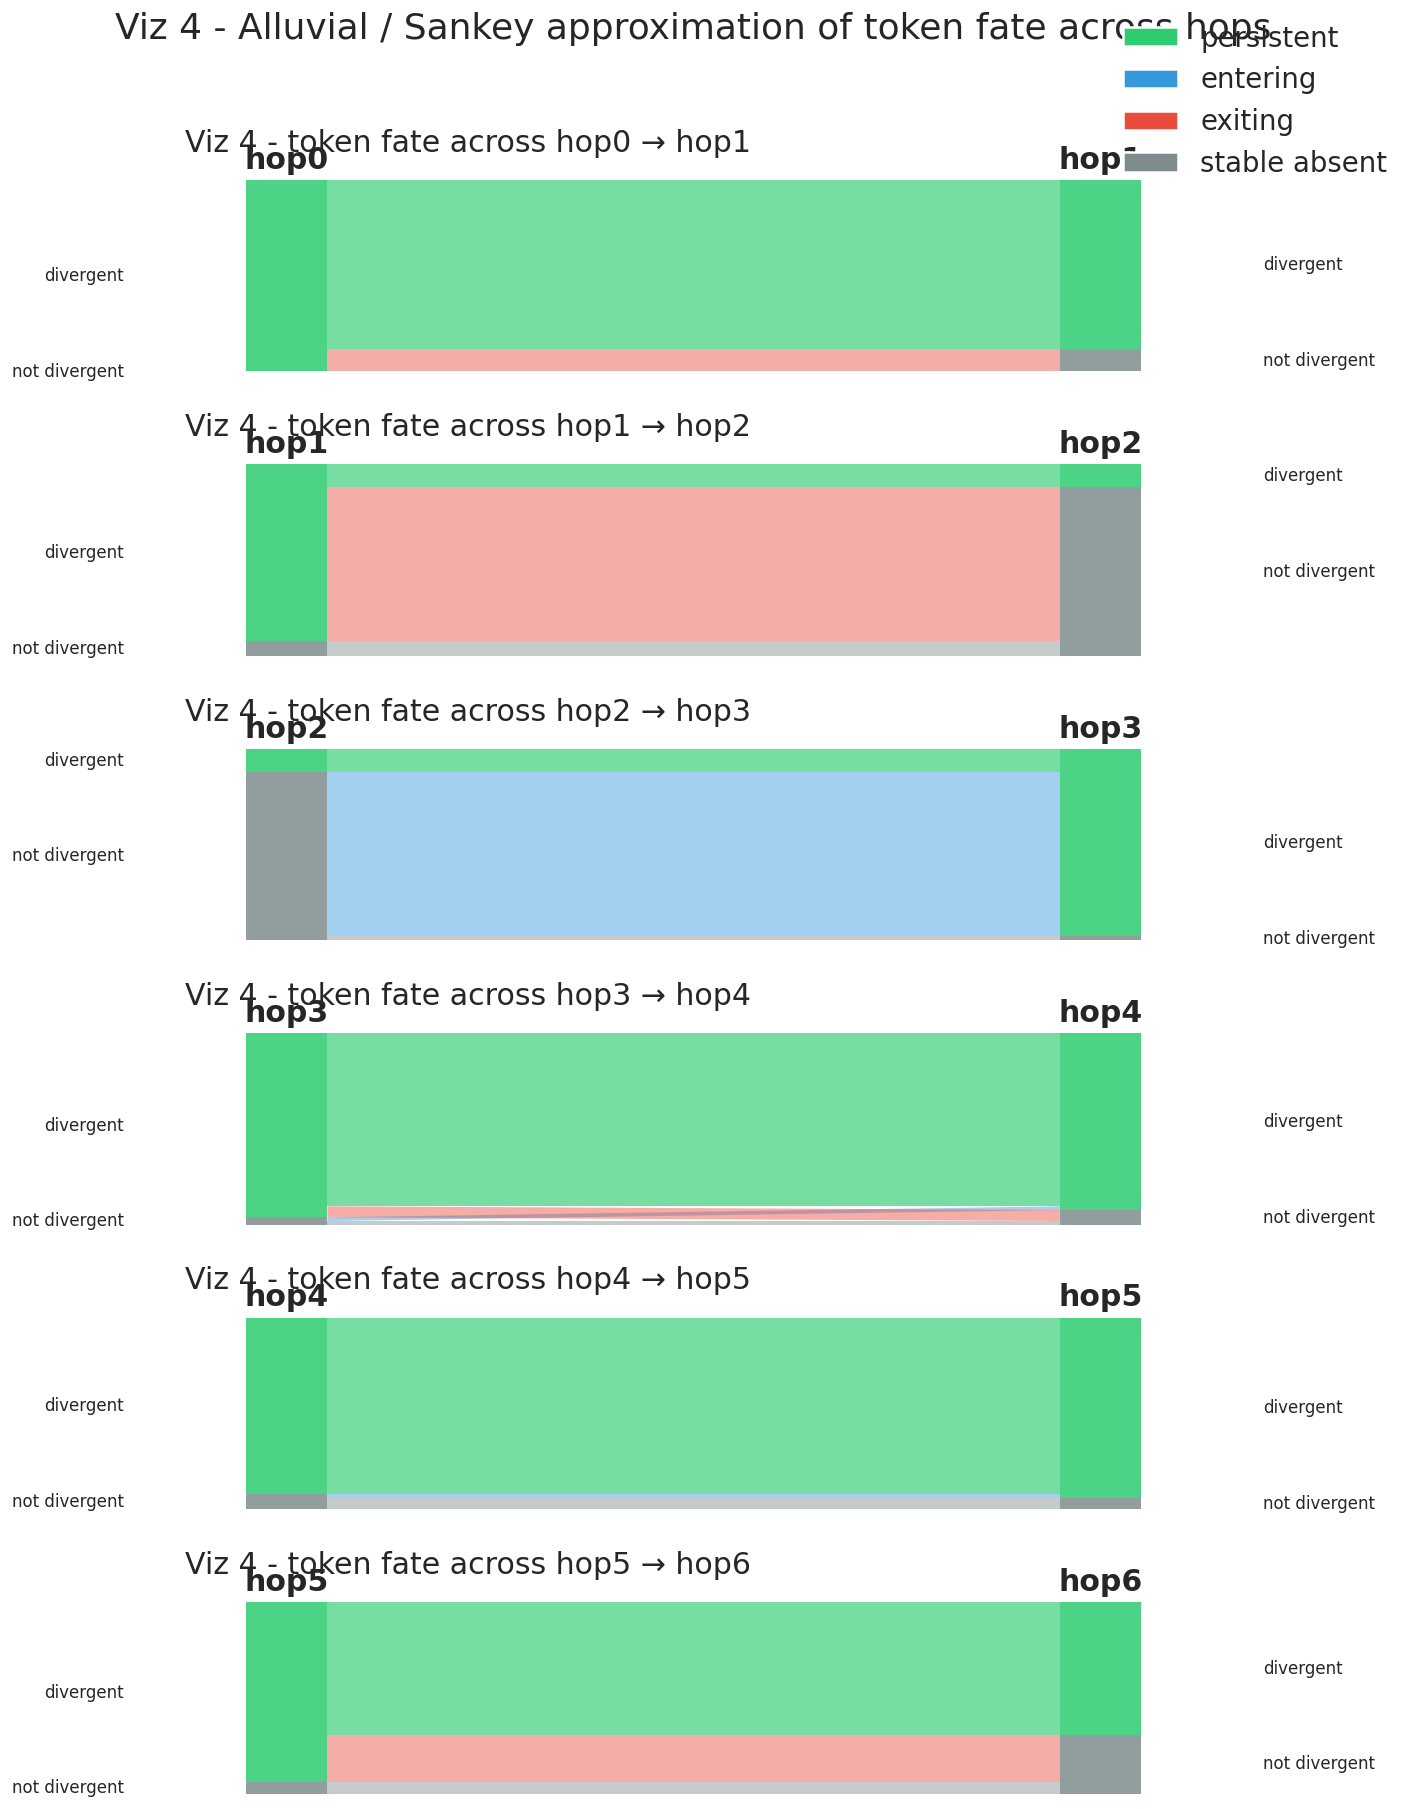

In [17]:
def draw_alluvial_transition(ax, transition, left_label, right_label):
    colors = {
        (0, 0): "#7f8c8d",
        (0, 1): "#3498db",
        (1, 0): "#e74c3c",
        (1, 1): "#2ecc71",
    }
    left_totals = transition.sum(axis=1)
    right_totals = transition.sum(axis=0)
    total = int(left_totals.sum())
    if total == 0:
        ax.set_axis_off()
        ax.set_title(f"{left_label} → {right_label} (no comparable positions)")
        return

    x_left, x_right = 0.1, 0.9
    bar_w = 0.08
    left_offsets = {0: 0.0, 1: float(left_totals[0])}
    right_offsets = {0: 0.0, 1: float(right_totals[0])}

    flows = []
    for src in (0, 1):
        for tgt in (0, 1):
            count = float(transition[src, tgt])
            if count == 0:
                continue
            y0_lo = left_offsets[src]
            y0_hi = y0_lo + count
            y1_lo = right_offsets[tgt]
            y1_hi = y1_lo + count
            left_offsets[src] = y0_hi
            right_offsets[tgt] = y1_hi
            flows.append((src, tgt, y0_lo, y0_hi, y1_lo, y1_hi))

    ax.add_patch(patches.Rectangle((x_left - bar_w / 2, 0), bar_w, left_totals[0], facecolor="#7f8c8d", edgecolor="none", alpha=0.85))
    ax.add_patch(patches.Rectangle((x_left - bar_w / 2, left_totals[0]), bar_w, left_totals[1], facecolor="#2ecc71", edgecolor="none", alpha=0.85))
    ax.add_patch(patches.Rectangle((x_right - bar_w / 2, 0), bar_w, right_totals[0], facecolor="#7f8c8d", edgecolor="none", alpha=0.85))
    ax.add_patch(patches.Rectangle((x_right - bar_w / 2, right_totals[0]), bar_w, right_totals[1], facecolor="#2ecc71", edgecolor="none", alpha=0.85))

    for src, tgt, y0_lo, y0_hi, y1_lo, y1_hi in flows:
        ribbon = patches.Polygon(
            [
                (x_left + bar_w / 2, y0_lo),
                (x_left + bar_w / 2, y0_hi),
                (x_right - bar_w / 2, y1_hi),
                (x_right - bar_w / 2, y1_lo),
            ],
            closed=True,
            facecolor=colors[(src, tgt)],
            edgecolor="none",
            alpha=0.45 if (src, tgt) != (1, 1) else 0.65,
        )
        ax.add_patch(ribbon)

    ax.text(x_left, total + total * 0.03, left_label, ha="center", va="bottom", fontweight="bold")
    ax.text(x_right, total + total * 0.03, right_label, ha="center", va="bottom", fontweight="bold")
    ax.text(x_left - 0.16, left_totals[0] / 2 if left_totals[0] else 0.0, "not divergent", ha="right", va="center", fontsize=10)
    ax.text(x_left - 0.16, left_totals[0] + left_totals[1] / 2 if left_totals[1] else left_totals[0], "divergent", ha="right", va="center", fontsize=10)
    ax.text(x_right + 0.16, right_totals[0] / 2 if right_totals[0] else 0.0, "not divergent", ha="left", va="center", fontsize=10)
    ax.text(x_right + 0.16, right_totals[0] + right_totals[1] / 2 if right_totals[1] else right_totals[0], "divergent", ha="left", va="center", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, total * 1.08)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

transition_matrices = []
for hop_idx in range(len(HOPS) - 1):
    transition_matrices.append(
        compute_transition_matrix(
            hop_aggregate_masks[hop_idx],
            hop_aggregate_masks[hop_idx + 1],
            hop_aggregate_valids[hop_idx],
            hop_aggregate_valids[hop_idx + 1],
        )
    )

fig, axes = plt.subplots(len(transition_matrices), 1, figsize=(12, 2.5 * len(transition_matrices)), constrained_layout=True)
if len(transition_matrices) == 1:
    axes = [axes]
for ax, transition, left_name, right_name in zip(axes, transition_matrices, HOPS[:-1], HOPS[1:]):
    draw_alluvial_transition(ax, transition, left_name, right_name)
    ax.set_title(f"Viz 4 - token fate across {left_name} → {right_name}", loc="left", pad=8)
legend_handles = [
    patches.Patch(facecolor="#2ecc71", label="persistent"),
    patches.Patch(facecolor="#3498db", label="entering"),
    patches.Patch(facecolor="#e74c3c", label="exiting"),
    patches.Patch(facecolor="#7f8c8d", label="stable absent"),
]
fig.legend(handles=legend_handles, loc="upper right", frameon=False)
fig.suptitle("Viz 4 - Alluvial / Sankey approximation of token fate across hops", y=1.01)
fig.tight_layout()
save_figure(fig, "viz4_alluvial_token_fate")
plt.show()


## Alluvial / Sankey approximation

This is the one plot that benefits from a small amount of hand-written geometry. I am using `matplotlib.patches.Polygon` to draw token-flow ribbons between consecutive hops, which keeps the notebook dependency-light while still showing how divergence is created, preserved, or lost.


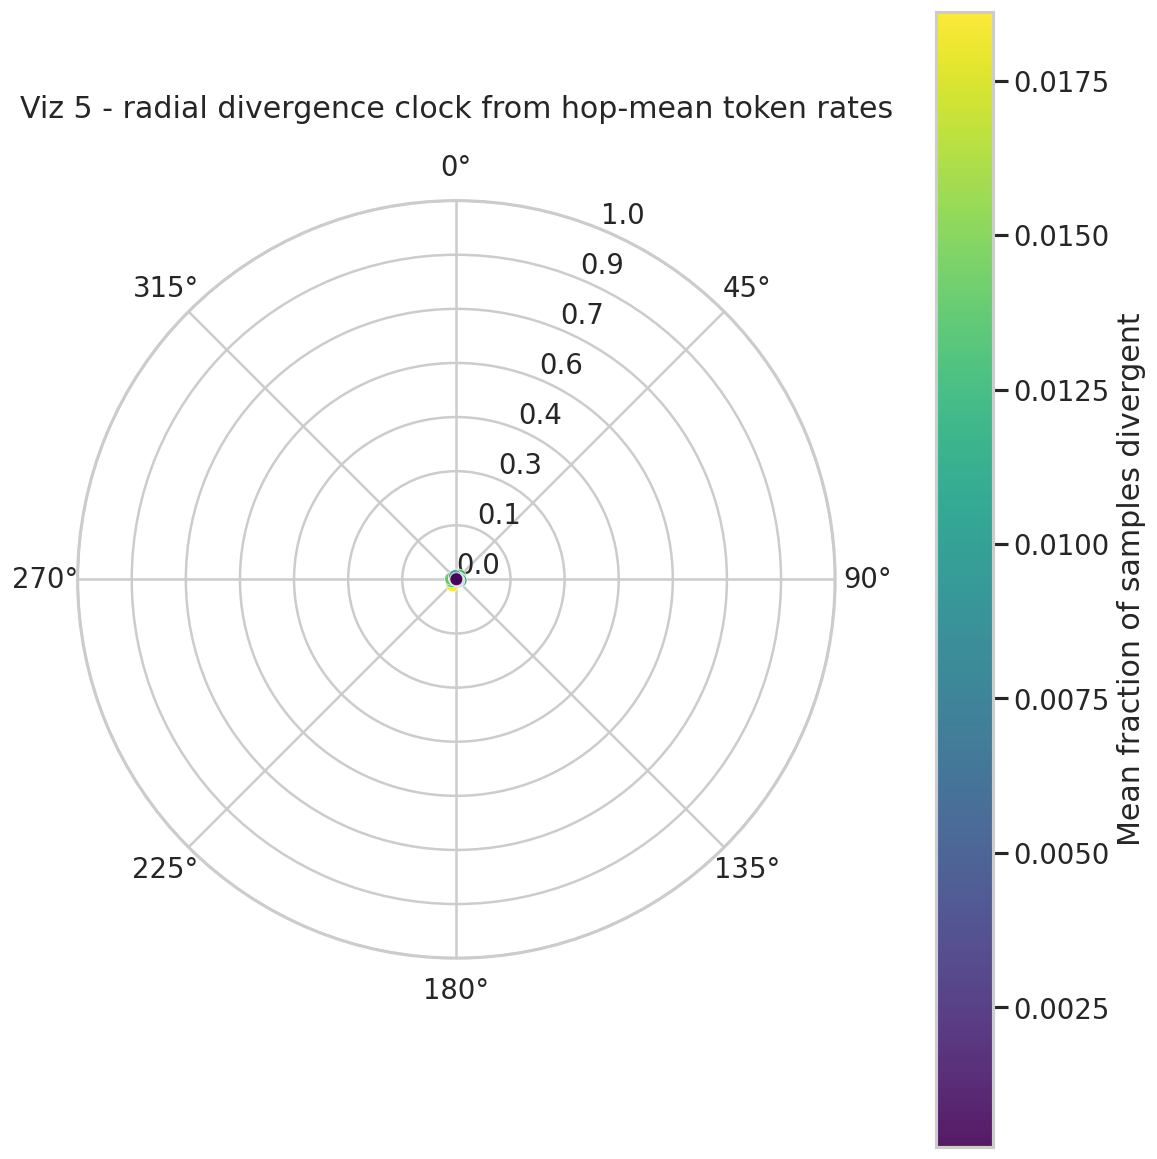

In [18]:
mean_position_rate = np.nanmean(hop_position_rates, axis=0)
valid_positions = np.isfinite(mean_position_rate)
positions = np.arange(mean_position_rate.shape[0])[valid_positions]
angles = 2 * np.pi * positions / max(1, mean_position_rate.shape[0])
radii = mean_position_rate[valid_positions]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "polar"})
scatter = ax.scatter(
    angles,
    radii,
    c=radii,
    cmap="viridis",
    s=60,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.4,
)
ax.set_title("Viz 5 - radial divergence clock from hop-mean token rates", pad=22)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlim(0, 1.0)
ax.set_yticks(np.linspace(0.0, 1.0, len(HOPS) + 1))
ax.set_yticklabels([f"{value:.1f}" for value in np.linspace(0.0, 1.0, len(HOPS) + 1)])
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Mean fraction of samples divergent")
fig.tight_layout()
save_figure(fig, "viz5_radial_divergence_clock")
plt.show()


## Radial divergence clock

This plot arranges token positions around a circle and uses the radius to encode how many hops a position was marked divergent in the selected sample. It is mostly a documentation plot: visually distinctive, but still driven by the same masks as the other figures.


## Closing notes

- To switch experiments, edit the configuration cell and change `MODEL`, `TARGET`, or `HOPS`.
- The notebook saves figures under `notebooks/div_points_analysis/divergence_token_fate_visualizations/figures`.
- The synthetic section is not decoration; it is the guardrail that catches mask-shape mistakes before the real plots run.
